# Breast Cancer Wisconsin — Exploratory Data Analysis

In this notebook we explore the **Breast Cancer Wisconsin (Diagnostic)** dataset to understand the data, find patterns, and identify features that distinguish malignant from benign tumors.

**Dataset**: 569 fine-needle aspirate (FNA) samples with 30 numeric features describing cell-nucleus characteristics, plus a binary diagnosis (malignant or benign).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/breast_cancer.csv")
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df.describe().round(3)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,3.037183e+07,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,1.250206e+08,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,8.670000e+03,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,8.692180e+05,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,9.060240e+05,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,8.813129e+06,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,9.113205e+08,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique IDs    : {df['id'].nunique()} (should equal {len(df)})")

Duplicate rows: 0
Unique IDs    : 569 (should equal 569)


## 4. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
total = missing.sum()
print(f"Total missing values: {total}")
if total:
    print(missing[missing > 0])
else:
    print("No missing values.")

Total missing values: 0
No missing values.


## 5. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_35027/853126169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette="Set2", ax=axes[0], order=["B", "M"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_35027/853126169.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Benign (B)", "Malignant (M)"])


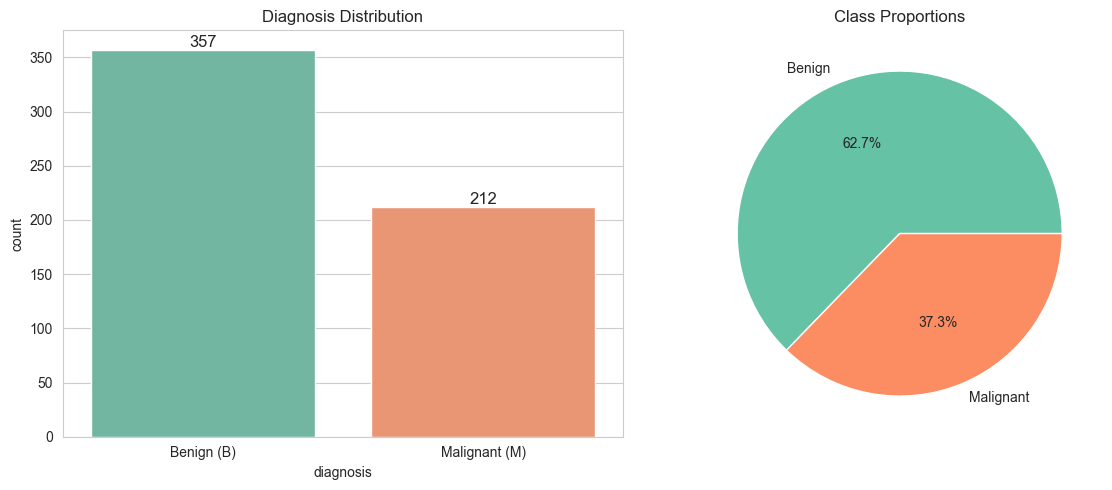

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="diagnosis", data=df, palette="Set2", ax=axes[0], order=["B", "M"])
axes[0].set_xticklabels(["Benign (B)", "Malignant (M)"])
axes[0].set_title("Diagnosis Distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

df["diagnosis"].value_counts().plot.pie(
    labels=["Benign", "Malignant"], autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"], ax=axes[1])
axes[1].set_ylabel("")
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

## 6. Univariate Analysis — Feature Distributions

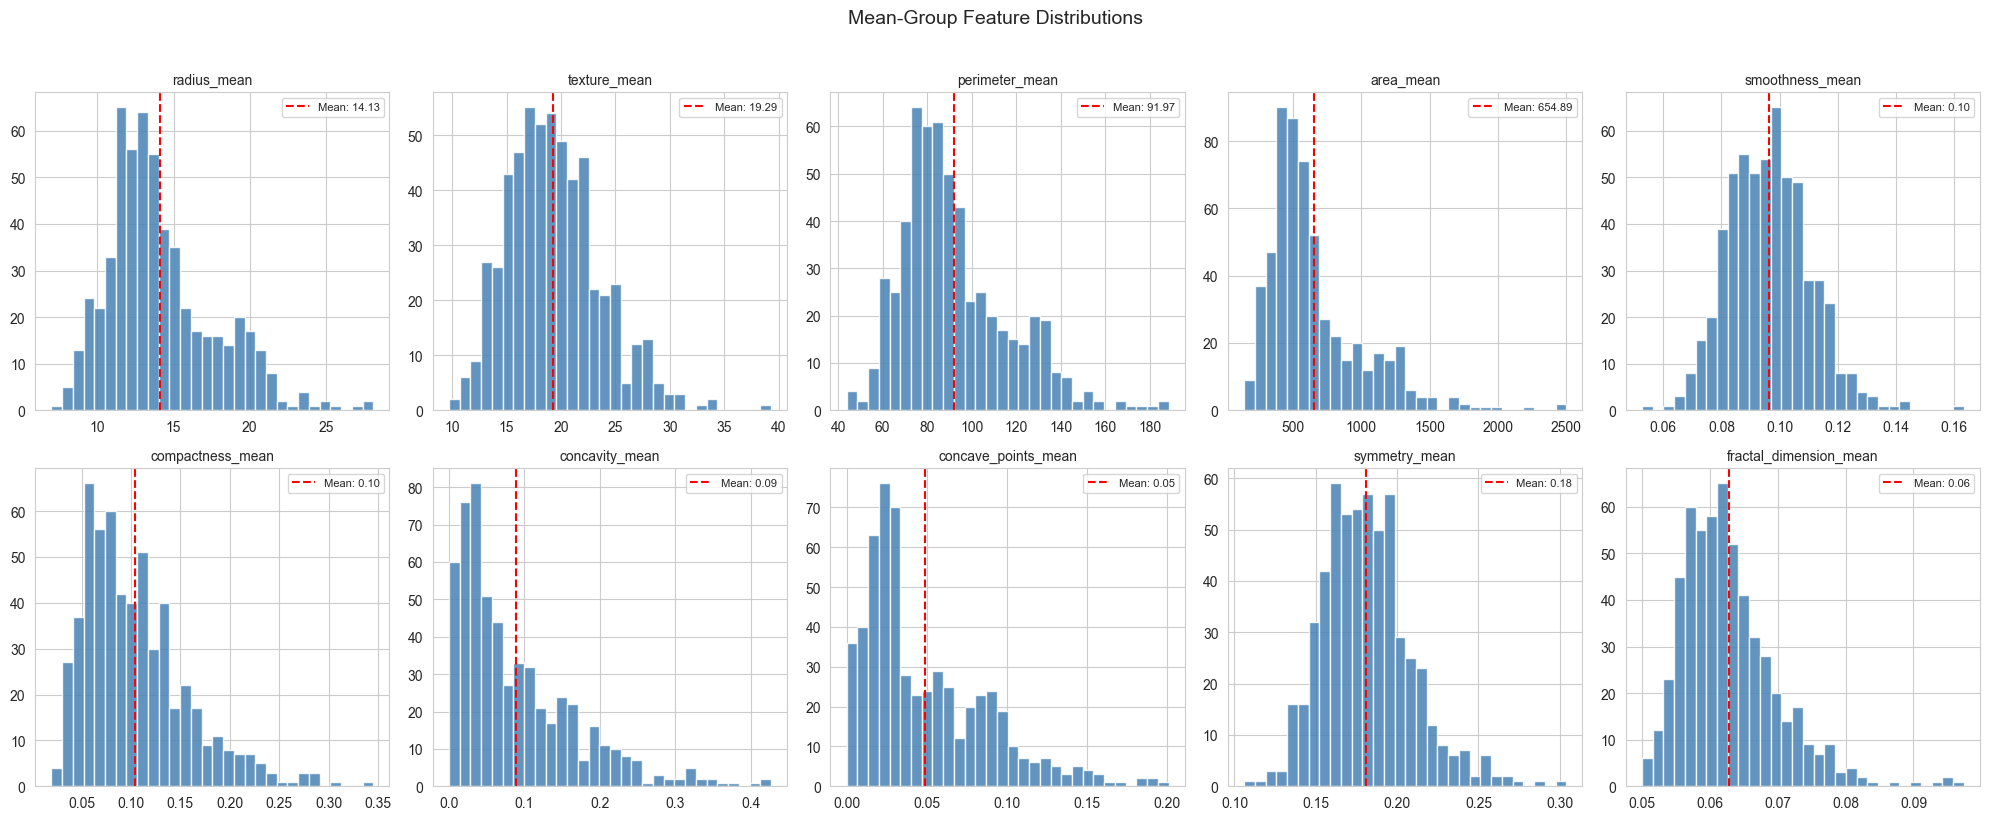

In [8]:
base = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
        'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
mean_features = [f"{f}_mean" for f in base]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle("Mean-Group Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

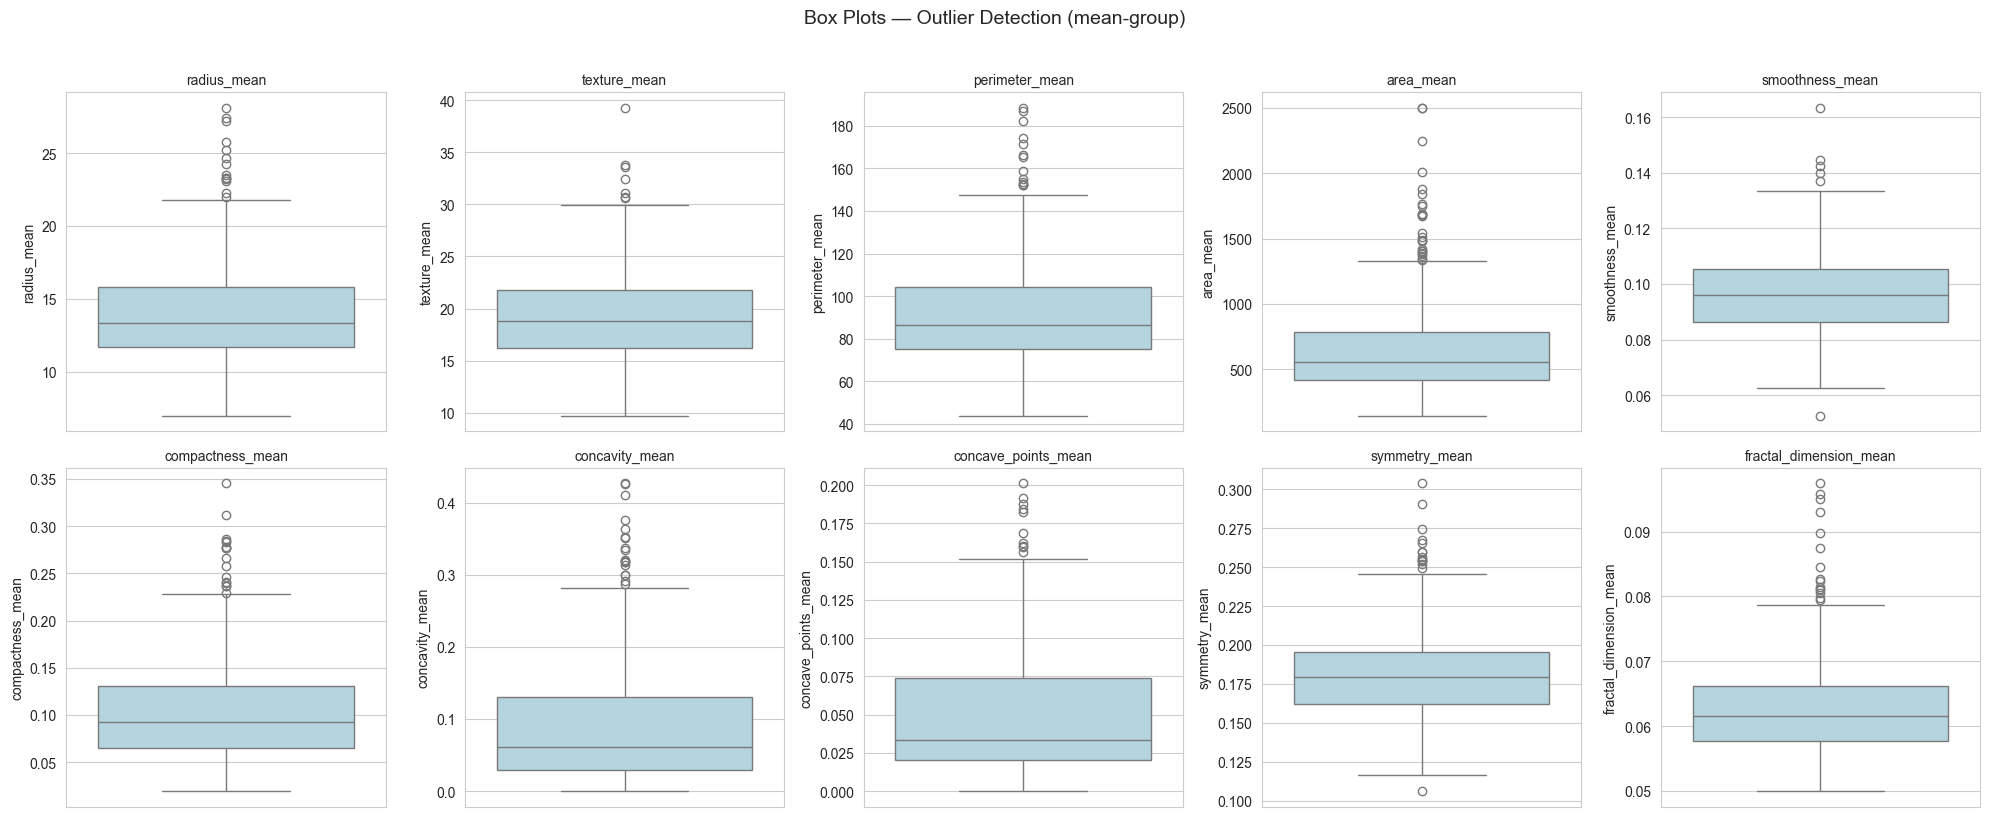

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col, fontsize=10)
plt.suptitle("Box Plots — Outlier Detection (mean-group)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features vs Diagnosis

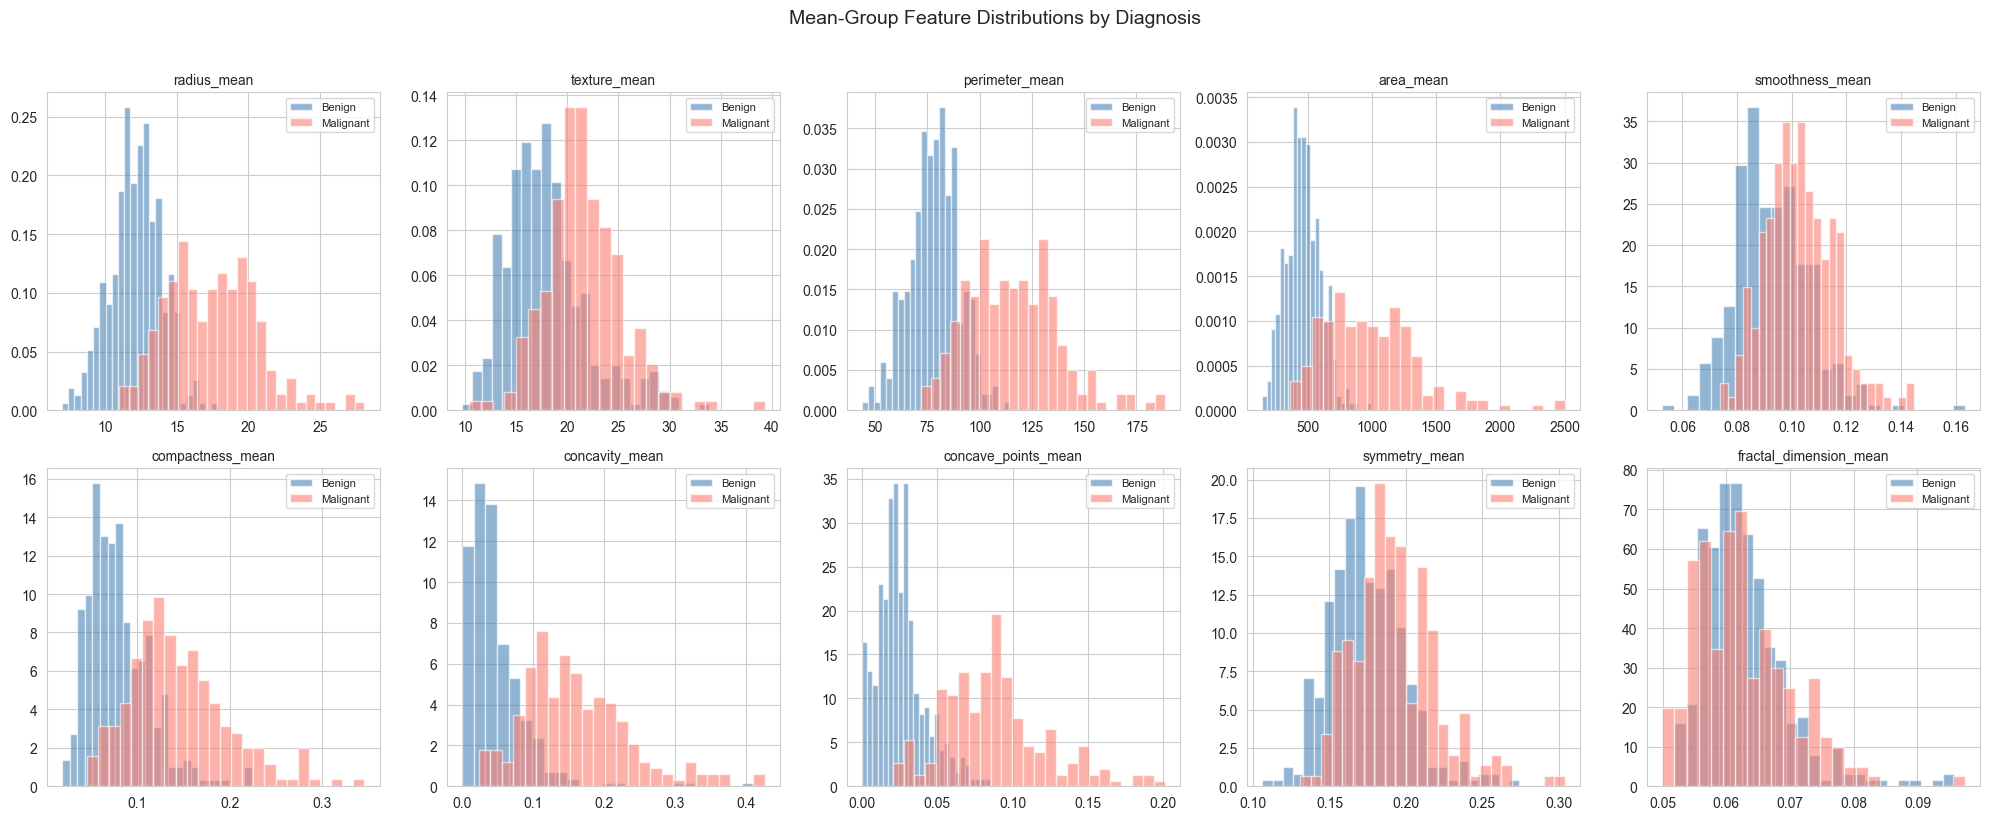

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    for diag, color, label in [("B", "steelblue", "Benign"), ("M", "salmon", "Malignant")]:
        subset = df[df["diagnosis"] == diag][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle("Mean-Group Feature Distributions by Diagnosis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
comparison = df.groupby("diagnosis")[mean_features].mean().T
comparison.columns = ["Benign", "Malignant"]
comparison["Difference"] = comparison["Malignant"] - comparison["Benign"]
comparison["% Higher"] = (comparison["Difference"] / comparison["Benign"] * 100).round(1)
comparison.round(3)

,Benign,Malignant,Difference,% Higher
radius_mean,12.147,17.463,5.316,43.8
texture_mean,17.915,21.605,3.690,20.6
perimeter_mean,78.075,115.365,37.290,47.8
area_mean,462.790,978.376,515.586,111.4
smoothness_mean,0.092,0.103,0.010,11.3
compactness_mean,0.080,0.145,0.065,81.3
concavity_mean,0.046,0.161,0.115,249.1
concave_points_mean,0.026,0.088,0.062,242.1
symmetry_mean,0.174,0.193,0.019,10.7
fractal_dimension_mean,0.063,0.063,-0.000,-0.3


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_35027/3131563895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="diagnosis", y=col, data=df, palette="Set2",
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_35027/3131563895.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Benign", "Malignant"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_35027/3131563895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="diagnosis", y=col, data=df, palette="Set2",
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_35027/3131563895.py:6:

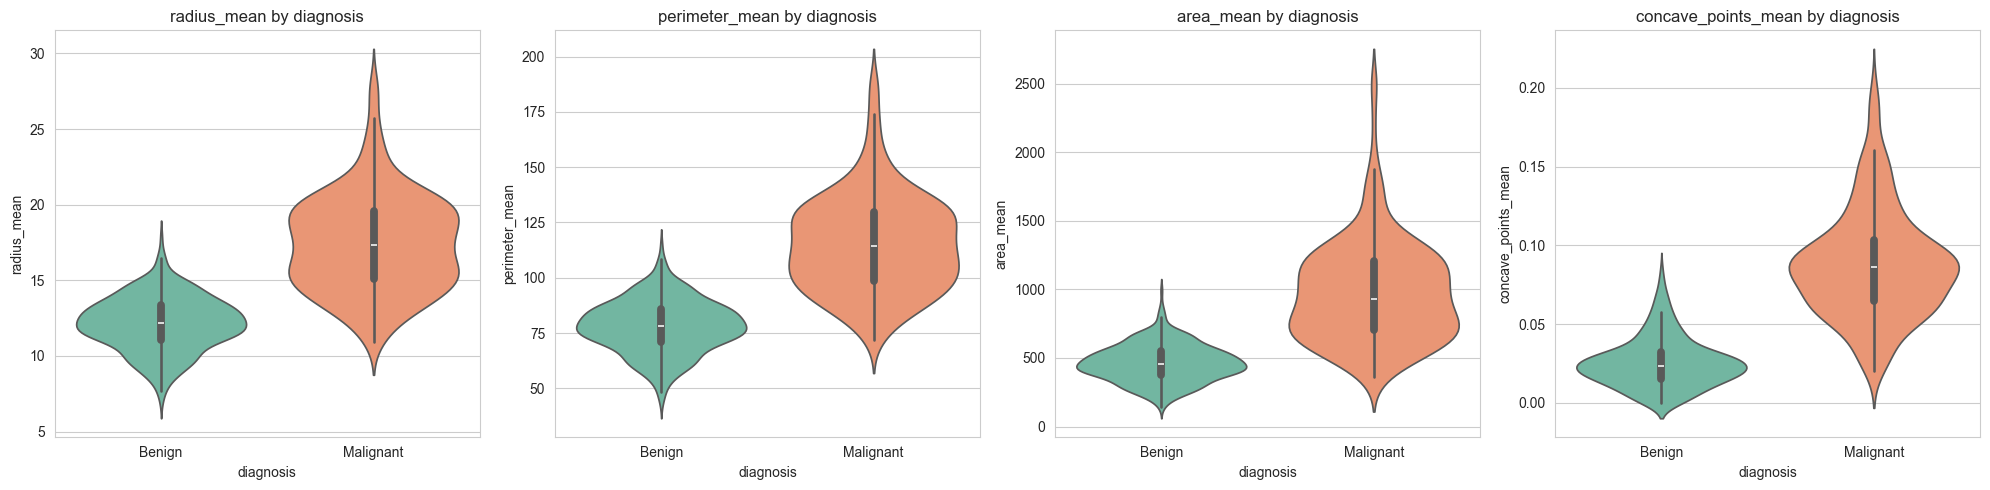

In [12]:
key = ["radius_mean", "perimeter_mean", "area_mean", "concave_points_mean"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(key):
    sns.violinplot(x="diagnosis", y=col, data=df, palette="Set2",
                   order=["B", "M"], ax=axes[i])
    axes[i].set_xticklabels(["Benign", "Malignant"])
    axes[i].set_title(f"{col} by diagnosis")
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

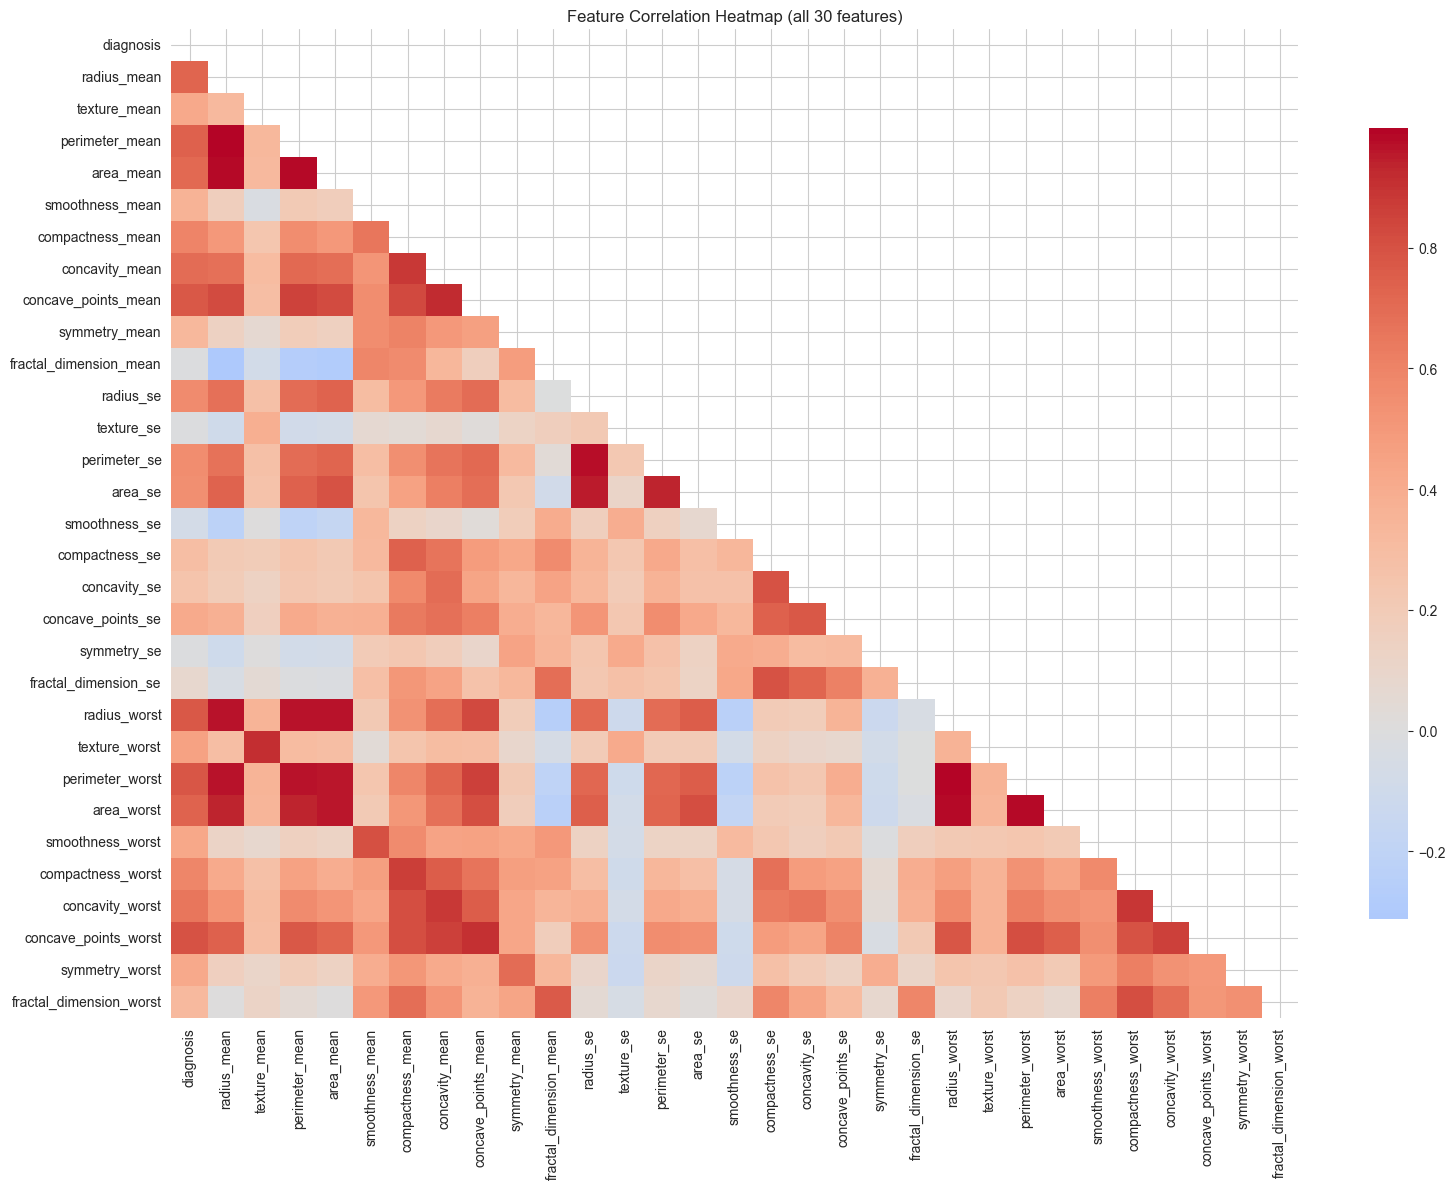

In [13]:
df_num = df.drop(columns=["id"]).copy()
df_num["diagnosis"] = df_num["diagnosis"].map({"B": 0, "M": 1})

plt.figure(figsize=(16, 12))
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=False,
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap (all 30 features)")
plt.tight_layout()
plt.show()

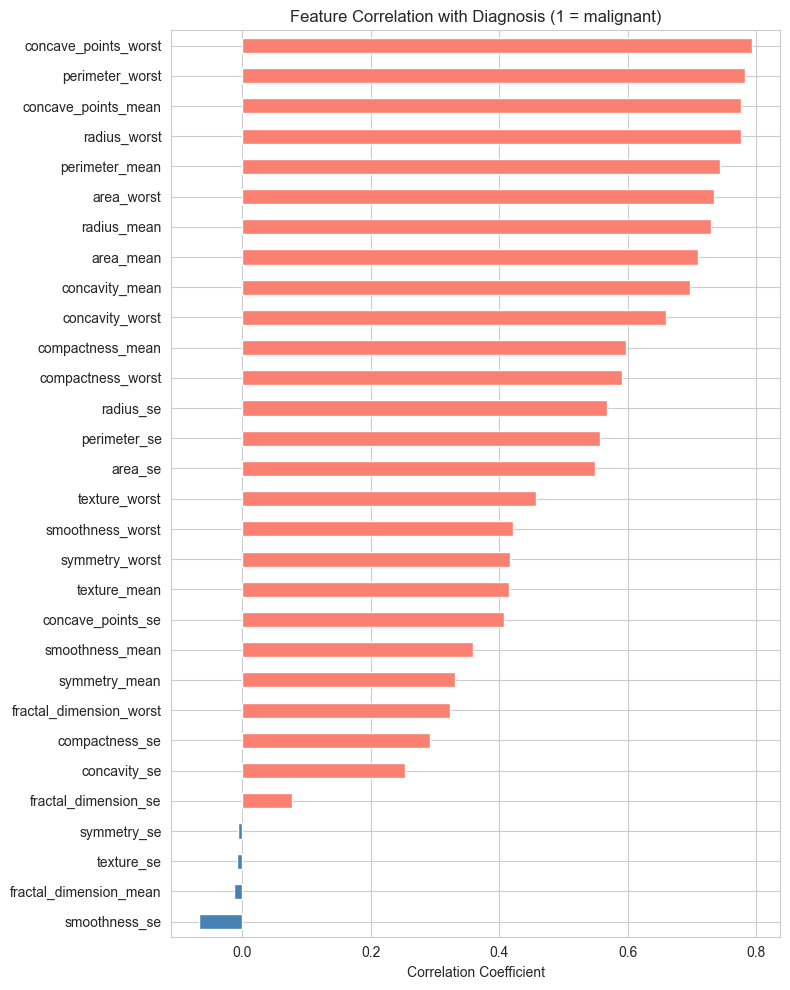

Top 10 features by correlation with diagnosis:
concave_points_worst    0.794
perimeter_worst         0.783
concave_points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
Name: diagnosis, dtype: float64


In [14]:
target_corr = df_num.corr()["diagnosis"].drop("diagnosis").sort_values(ascending=False)

plt.figure(figsize=(8, 10))
target_corr.plot(kind="barh", color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature Correlation with Diagnosis (1 = malignant)")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features by correlation with diagnosis:")
print(target_corr.head(10).round(3))

## 9. Mean vs Worst — Tumor Heterogeneity Analysis

The "worst" group captures the largest values seen in any region of the tumor. Comparing it to the mean group helps us see how heterogeneous a tumor is.

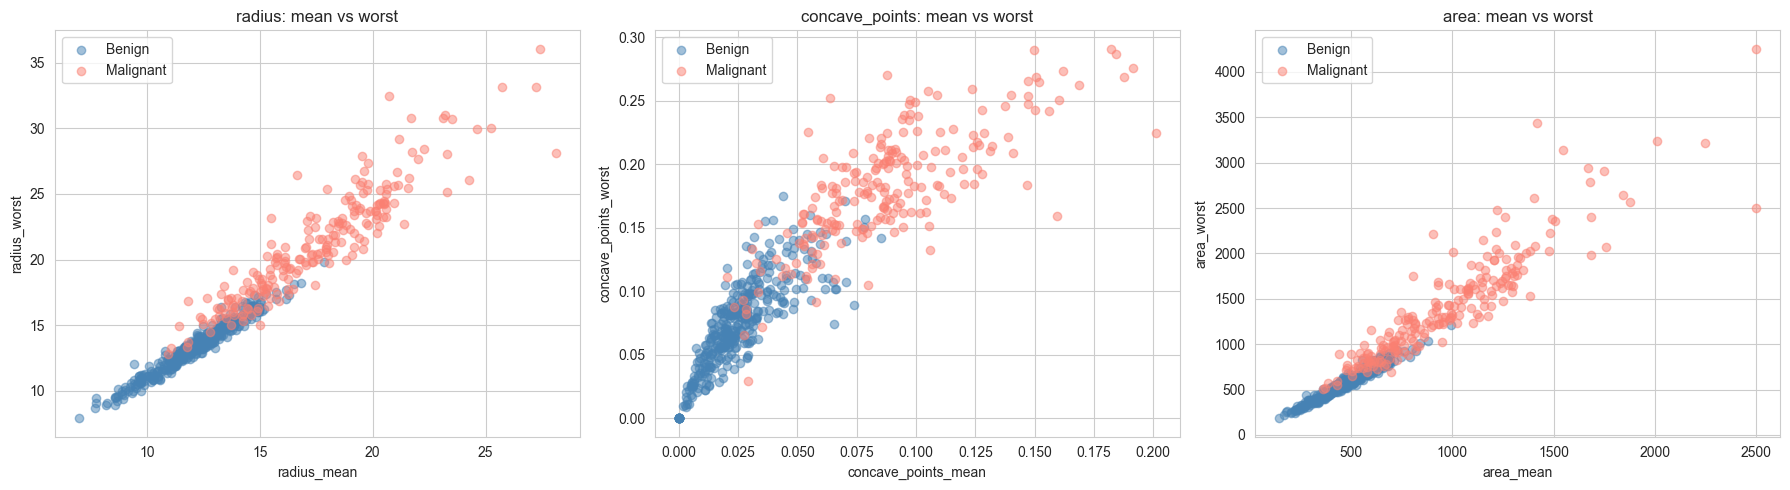

In [15]:
pairs = ["radius", "concave_points", "area"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, p in enumerate(pairs):
    for diag, color, label in [("B", "steelblue", "Benign"), ("M", "salmon", "Malignant")]:
        subset = df[df["diagnosis"] == diag]
        axes[i].scatter(subset[f"{p}_mean"], subset[f"{p}_worst"],
                        c=color, alpha=0.5, label=label)
    axes[i].set_xlabel(f"{p}_mean")
    axes[i].set_ylabel(f"{p}_worst")
    axes[i].set_title(f"{p}: mean vs worst")
    axes[i].legend()
plt.tight_layout()
plt.show()

## 10. Pair Plot of Top Predictors

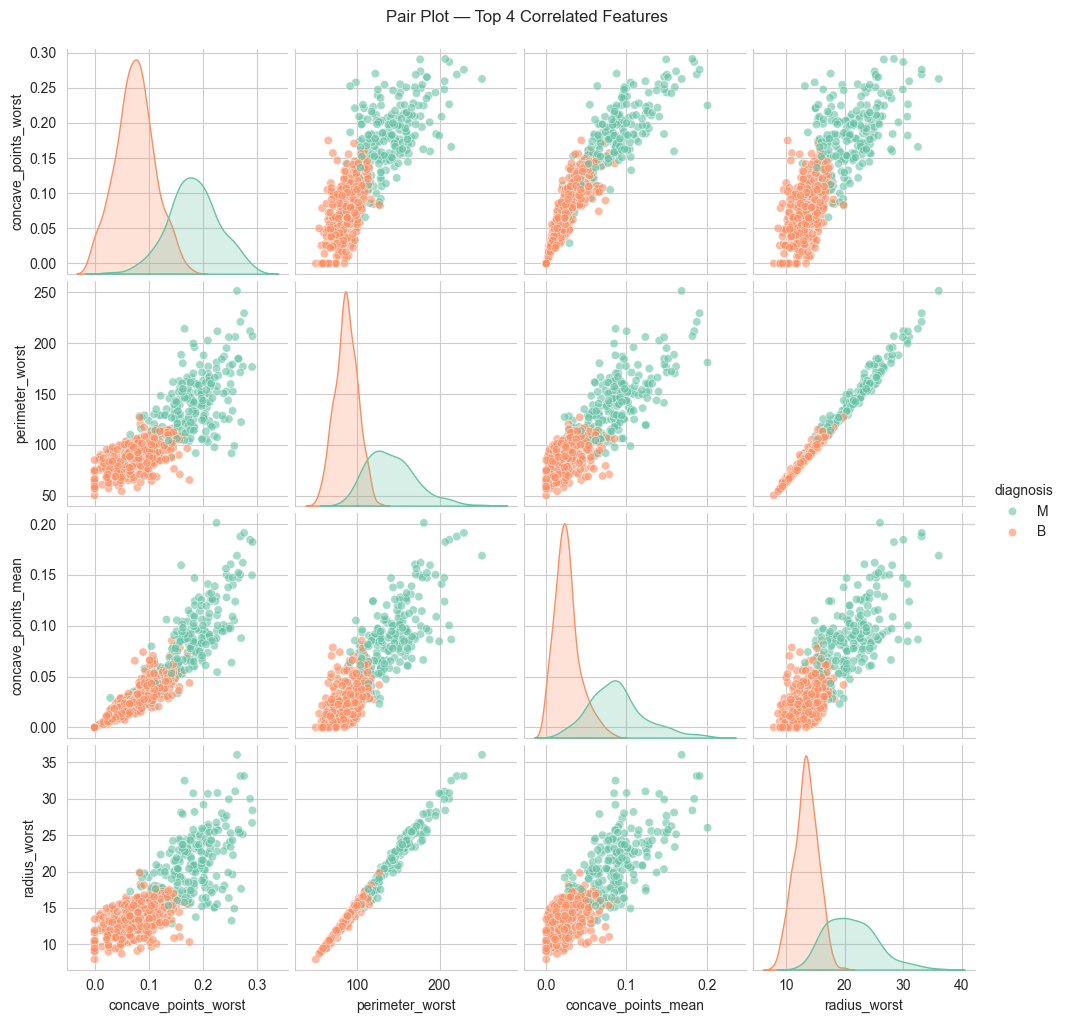

In [16]:
top = ["concave_points_worst", "perimeter_worst", "concave_points_mean", "radius_worst", "diagnosis"]
df_top = df.copy()
sns.pairplot(df_top[top], hue="diagnosis", palette="Set2",
             diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pair Plot — Top 4 Correlated Features", y=1.02)
plt.show()

## 11. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Class balance**: ~63% benign vs ~37% malignant — moderately imbalanced |
| 2 | **No missing values** — UCI WDBC is already clean |
| 3 | **Strongest predictors** are nucleus shape features: `concave_points_worst`, `perimeter_worst`, `radius_worst`, `concave_points_mean` (all r > 0.78) |
| 4 | **Malignant tumors are larger and more irregular** — radius, perimeter, area, and concavity are all dramatically higher for class M |
| 5 | **Texture and fractal_dimension_mean** are the weakest predictors (r < 0.35) |
| 6 | **Heavy correlation between size features** — radius / perimeter / area cluster together; expect multicollinearity |
| 7 | **`worst` group features dominate** the top-10 importance list — the most-extreme cell in a tumor is more diagnostic than the average |